In [1]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


# 📈 Prophet Model — Weekly Expense Forecasting

**Goal:** Replace ARIMA base model with Facebook Prophet for better handling of
irregular, spike-driven personal expense data.

**Why Prophet over ARIMA:**
- ARIMA assumes smooth, stationary series — personal expenses are neither
- Prophet handles irregular spikes, missing weeks, and multiple seasonalities natively
- Prophet explicitly models Indian festival effects (Diwali, Holi, etc.)
- Produces interpretable trend + seasonality decomposition

**Pipeline:**
1. Load preprocessed weekly train/test data
2. Format data for Prophet (ds, y columns)
3. Define Indian festival holidays
4. Fit Prophet model
5. Forecast & evaluate (MAE, RMSE, MAPE)
6. Decomposition plot (trend + seasonality)
7. Save residuals for hybrid model
8. Save model + forecast outputs

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import pickle

from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

# ─── Paths ───────────────────────────────────────────────────
PROCESSED_DIR = 'data/processed'
ASSETS_DIR    = 'assets'
os.makedirs(ASSETS_DIR, exist_ok=True)

print('✅ All imports successful')

c:\Users\vetch\anaconda3\envs\ts_hybrid\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


✅ All imports successful


## ✅ Step 2: Load Preprocessed Weekly Data

In [4]:
# Load clean weekly train/test splits from preprocessing pipeline
train_df = pd.read_csv(f'{PROCESSED_DIR}/train_monthly1.csv', parse_dates=['date'])
test_df  = pd.read_csv(f'{PROCESSED_DIR}/test_monthly1.csv',  parse_dates=['date'])

# Prophet requires columns named exactly 'ds' (date) and 'y' (value)
train_prophet = train_df.rename(columns={'date': 'ds', 'amount': 'y'})[['ds', 'y']]
test_prophet  = test_df.rename(columns={'date': 'ds', 'amount': 'y'})[['ds', 'y']]

print(f'📅 Train: {train_prophet["ds"].min().date()} → {train_prophet["ds"].max().date()}  ({len(train_prophet)} weeks)')
print(f'📅 Test : {test_prophet["ds"].min().date()} → {test_prophet["ds"].max().date()}   ({len(test_prophet)} weeks)')
print(f'\n📊 Train stats:')
print(train_prophet['y'].describe().round(2))

📅 Train: 2020-01-31 → 2024-06-30  (54 weeks)
📅 Test : 2024-07-31 → 2024-12-31   (6 weeks)

📊 Train stats:
count       54.00
mean      4219.30
std       3904.63
min        386.00
25%       1689.75
50%       2639.11
75%       5830.48
max      21748.00
Name: y, dtype: float64


## ✅ Step 3: Define Indian Festival Holidays

Prophet allows explicit holiday effects — spending spikes during festivals
are a known pattern in Indian personal finance data.

In [5]:
# Indian festivals — dates covering 2020-2025 training window
# lower_window/upper_window: how many days before/after the holiday to model effect

holidays = pd.DataFrame({
    'holiday': [
        # Diwali — biggest spending spike of the year
        'diwali', 'diwali', 'diwali', 'diwali', 'diwali',
        # Holi
        'holi', 'holi', 'holi', 'holi', 'holi',
        # Eid
        'eid', 'eid', 'eid', 'eid', 'eid',
        # New Year
        'new_year', 'new_year', 'new_year', 'new_year', 'new_year',
        # Onam (South India — relevant for your Coimbatore context)
        'onam', 'onam', 'onam', 'onam', 'onam',
    ],
    'ds': pd.to_datetime([
        # Diwali dates
        '2020-11-14', '2021-11-04', '2022-10-24', '2023-11-12', '2024-11-01',
        # Holi dates
        '2020-03-10', '2021-03-29', '2022-03-18', '2023-03-08', '2024-03-25',
        # Eid dates (approximate)
        '2020-05-24', '2021-05-13', '2022-05-02', '2023-04-21', '2024-04-10',
        # New Year
        '2020-01-01', '2021-01-01', '2022-01-01', '2023-01-01', '2024-01-01',
        # Onam
        '2020-08-31', '2021-08-21', '2022-09-08', '2023-09-28', '2024-09-15',
    ]),
    'lower_window': [-3, -3, -3, -3, -3,   # 3 days before
                     -2, -2, -2, -2, -2,
                     -1, -1, -1, -1, -1,
                     -1, -1, -1, -1, -1,
                     -2, -2, -2, -2, -2],
    'upper_window': [ 3,  3,  3,  3,  3,   # 3 days after
                      2,  2,  2,  2,  2,
                      1,  1,  1,  1,  1,
                      2,  2,  2,  2,  2,
                      2,  2,  2,  2,  2],
})

print(f'✅ Defined {len(holidays)} holiday data points across {holidays["holiday"].nunique()} festivals')
print(holidays.groupby('holiday')['ds'].count())

✅ Defined 25 holiday data points across 5 festivals
holiday
diwali      5
eid         5
holi        5
new_year    5
onam        5
Name: ds, dtype: int64


## ✅ Step 4: Configure & Fit Prophet Model

In [6]:
model = Prophet(
    # ── Trend ────────────────────────────────────────────────
    growth='linear',              # linear trend (flat overall direction)
    changepoint_prior_scale=0.1,  # flexibility of trend changes
                                  # higher = more flexible, lower = smoother
                                  # 0.1 is good for personal finance
    n_changepoints=25,            # number of potential trend change points

    # ── Seasonality ──────────────────────────────────────────
    yearly_seasonality=True,      # annual patterns (festive seasons, year-end)
    weekly_seasonality=False,     # we're using weekly aggregates already
    daily_seasonality=False,      # not applicable for weekly data
    seasonality_prior_scale=10,   # strength of seasonality effect
    seasonality_mode='multiplicative',  # spending MULTIPLIES in festive seasons
                                        # better than additive for expense data

    # ── Holidays ─────────────────────────────────────────────
    holidays=holidays,
    holidays_prior_scale=10,      # strength of holiday effect

    # ── Uncertainty ──────────────────────────────────────────
    interval_width=0.80,          # 80% confidence intervals on forecast
)

# Add monthly seasonality manually (Prophet doesn't do this automatically)
model.add_seasonality(
    name='monthly',
    period=30.5,
    fourier_order=5              # complexity of monthly pattern
)

print('🔄 Fitting Prophet model...')
model.fit(train_prophet)
print('✅ Prophet model fitted successfully')

08:17:16 - cmdstanpy - INFO - Chain [1] start processing


🔄 Fitting Prophet model...


08:17:18 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model fitted successfully


## ✅ Step 5: Generate Forecast on Test Period

In [7]:
# Create future dataframe using test dates
# We use actual test dates so forecast aligns with evaluation period
future = test_prophet[['ds']].copy()

# Generate forecast
forecast = model.predict(future)

# Extract relevant columns
forecast_out = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_out.columns = ['date', 'forecast', 'forecast_lower', 'forecast_upper']

# Clip negative forecasts to 0 (expenses can't be negative)
forecast_out['forecast']       = forecast_out['forecast'].clip(lower=0)
forecast_out['forecast_lower'] = forecast_out['forecast_lower'].clip(lower=0)
forecast_out['forecast_upper'] = forecast_out['forecast_upper'].clip(lower=0)

print('📊 Forecast sample (first 6 weeks):')
print(forecast_out.head(6).to_string(index=False))

📊 Forecast sample (first 6 weeks):
      date    forecast  forecast_lower  forecast_upper
2024-07-31 4234.491850     1578.634299     7164.517971
2024-08-31 5199.970198     2489.228998     8298.081969
2024-09-30 1055.614005        0.000000     4090.378917
2024-10-31 7948.545742     5176.001509    10960.837226
2024-11-30 5538.081222     2809.148618     8351.393459
2024-12-31    0.000000        0.000000        0.000000


## ✅ Step 6: Evaluate Forecast Accuracy

In [9]:
actual   = test_prophet['y'].values
predicted = forecast_out['forecast'].values

mae  = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

# MAPE — exclude zero actuals to avoid division by zero
mask = actual != 0
mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

# Relative error
rel_error = mae / np.mean(actual) * 100

print('📊 Prophet Evaluation on Test Set')
print(f'   MAE            : {mae:.2f} INR')
print(f'   RMSE           : {rmse:.2f} INR')
print(f'   MAPE           : {mape:.2f}%')
print(f'   Relative Error : {rel_error:.2f}%')

# Week-by-week breakdown
comparison = pd.DataFrame({
    'date'    : test_prophet['ds'].values,
    'actual'  : actual.round(2),
    'forecast': predicted.round(2),
    'error'   : (actual - predicted).round(2),
    'APE (%)' : np.where(actual != 0,
                         np.abs((actual - predicted) / actual) * 100,
                         0).round(2)
})
print('\n📅 Week-by-week breakdown:')
print(comparison.to_string(index=False))


📊 Prophet Evaluation on Test Set
   MAE            : 3195.74 INR
   RMSE           : 3835.57 INR
   MAPE           : 57.76%
   Relative Error : 51.89%

📅 Week-by-week breakdown:
      date  actual  forecast    error  APE (%)
2024-07-31  8868.0   4234.49  4633.51    52.25
2024-08-31  4964.9   5199.97  -235.07     4.73
2024-09-30  6306.0   1055.61  5250.39    83.26
2024-10-31  5083.0   7948.55 -2865.55    56.38
2024-11-30 11063.0   5538.08  5524.92    49.94
2024-12-31   665.0      0.00   665.00   100.00


## ✅ Step 7: Visualize Forecast vs Actual

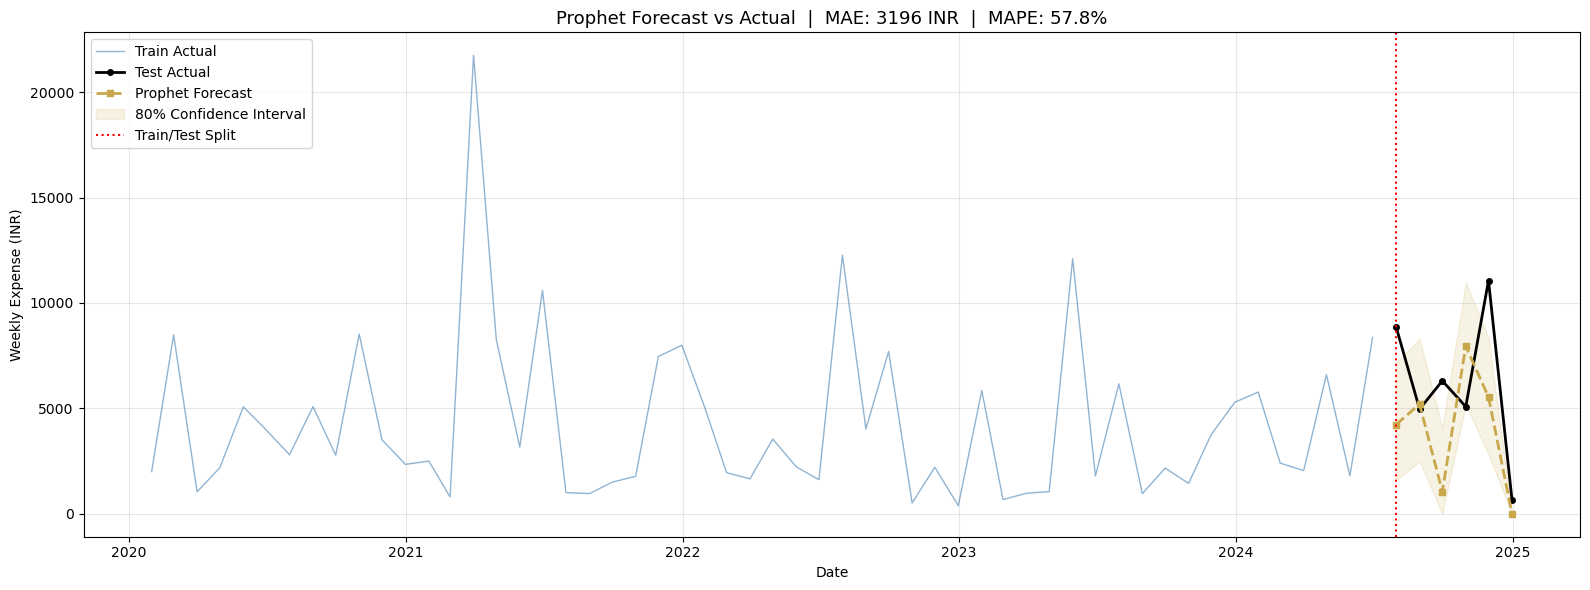

✅ Forecast plot saved


In [10]:
fig, ax = plt.subplots(figsize=(16, 6))

# Training data
ax.plot(train_prophet['ds'], train_prophet['y'],
        color='steelblue', linewidth=1, alpha=0.6, label='Train Actual')

# Test actual
ax.plot(test_prophet['ds'], test_prophet['y'],
        color='black', linewidth=2, marker='o', markersize=4, label='Test Actual')

# Prophet forecast
ax.plot(forecast_out['date'], forecast_out['forecast'],
        color='#C9A84C', linewidth=2, marker='s', markersize=4,
        linestyle='--', label='Prophet Forecast')

# Confidence interval
ax.fill_between(forecast_out['date'],
                forecast_out['forecast_lower'],
                forecast_out['forecast_upper'],
                alpha=0.15, color='#C9A84C', label='80% Confidence Interval')

ax.axvline(x=test_prophet['ds'].iloc[0], color='red',
           linestyle=':', linewidth=1.5, label='Train/Test Split')

ax.set_title(f'Prophet Forecast vs Actual  |  MAE: {mae:.0f} INR  |  MAPE: {mape:.1f}%',
             fontsize=13)
ax.set_ylabel('Weekly Expense (INR)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{ASSETS_DIR}/prophet_forecast.png', dpi=150)
plt.show()
print('✅ Forecast plot saved')

## ✅ Step 8: Decomposition Plot (Trend + Seasonality)

This is the key advantage of Prophet — interpretable components.
Use this in your paper and Razorpay pitch to explain what the model learned.

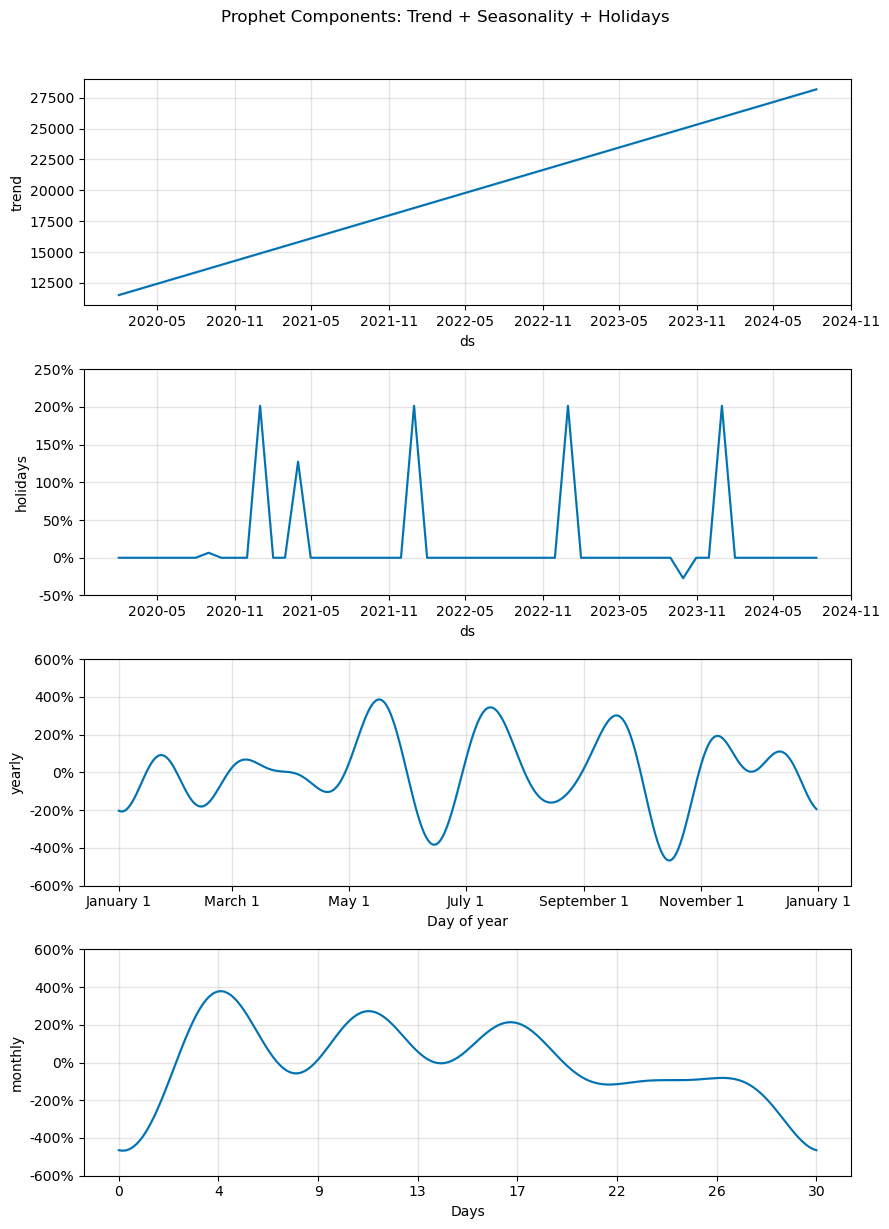

✅ Components plot saved

📌 Reading the decomposition:
   Trend     → overall direction of spending over 4.5 years
   Yearly    → which months you spend more/less
   Monthly   → within-month spending patterns
   Holidays  → festival spending spikes (Diwali, Holi, etc.)


In [11]:
# Generate full forecast including training period for decomposition
future_full = model.make_future_dataframe(periods=len(test_prophet), freq='W')
forecast_full = model.predict(future_full)

# Prophet's built-in decomposition plot
fig = model.plot_components(forecast_full)
plt.suptitle('Prophet Components: Trend + Seasonality + Holidays', y=1.02)
plt.tight_layout()
plt.savefig(f'{ASSETS_DIR}/prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Components plot saved')
print('\n📌 Reading the decomposition:')
print('   Trend     → overall direction of spending over 4.5 years')
print('   Yearly    → which months you spend more/less')
print('   Monthly   → within-month spending patterns')
print('   Holidays  → festival spending spikes (Diwali, Holi, etc.)')

## ✅ Step 9: Save Residuals for Hybrid Model

Residuals = what Prophet could NOT explain.
These are fed into GRU to capture the non-linear patterns Prophet missed.

📌 Residual mean : 8.54  (ideally ≈ 0)
📌 Residual std  : 2239.22
📌 Residuals > 0 : 25 weeks (Prophet underestimated)
📌 Residuals < 0 : 29 weeks (Prophet overestimated)


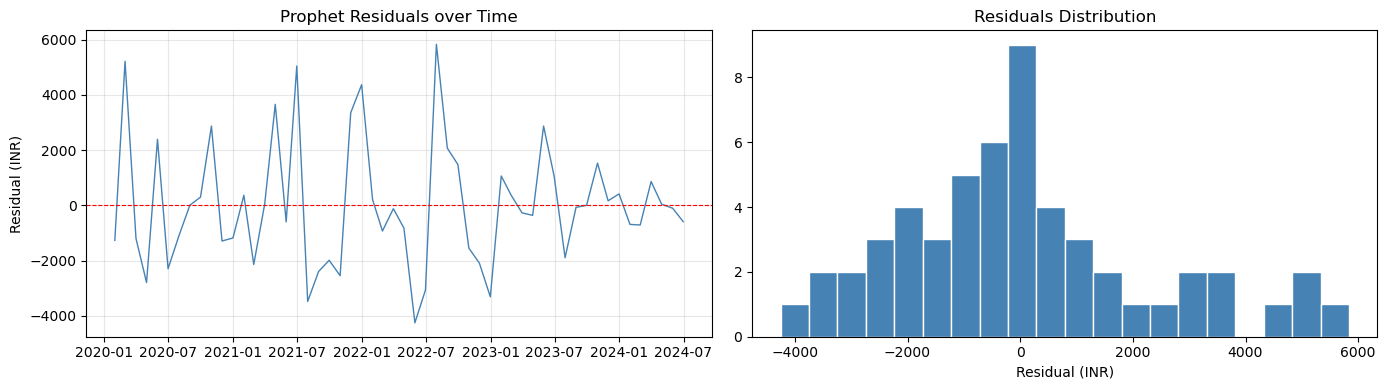

In [12]:
# In-sample prediction on training data
train_forecast = model.predict(train_prophet[['ds']])

# Residuals = actual - prophet prediction
residuals = train_prophet['y'].values - train_forecast['yhat'].values

residuals_df = pd.DataFrame({
    'date'     : train_prophet['ds'].values,
    'actual'   : train_prophet['y'].values,
    'prophet'  : train_forecast['yhat'].values.round(2),
    'residuals': residuals.round(2)
})

print(f'📌 Residual mean : {residuals.mean():.2f}  (ideally ≈ 0)')
print(f'📌 Residual std  : {residuals.std():.2f}')
print(f'📌 Residuals > 0 : {(residuals > 0).sum()} weeks (Prophet underestimated)')
print(f'📌 Residuals < 0 : {(residuals < 0).sum()} weeks (Prophet overestimated)')

# Plot residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(residuals_df['date'], residuals_df['residuals'],
             color='steelblue', linewidth=1)
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0].set_title('Prophet Residuals over Time')
axes[0].set_ylabel('Residual (INR)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals_df['residuals'].dropna(), bins=20,
             color='steelblue', edgecolor='white')
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residual (INR)')

plt.tight_layout()
plt.savefig(f'{ASSETS_DIR}/prophet_residuals.png', dpi=150)
plt.show()

## ✅ Step 10: Save All Outputs

In [13]:
# Save residuals for GRU hybrid model
residuals_df.to_csv(f'{PROCESSED_DIR}/prophet_residuals.csv', index=False)

# Save forecast for comparison notebook
comparison.to_csv(f'{PROCESSED_DIR}/prophet_forecast.csv', index=False)

# Save fitted model for backend API
with open(f'{ASSETS_DIR}/prophet_base.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save metrics for final comparison notebook
metrics = {
    'model' : 'Prophet',
    'MAE'   : round(mae, 2),
    'RMSE'  : round(rmse, 2),
    'MAPE'  : round(mape, 2),
    'RelErr': round(rel_error, 2)
}
pd.DataFrame([metrics]).to_csv(f'{PROCESSED_DIR}/prophet_metrics.csv', index=False)

print('✅ Saved:')
print(f'   → {PROCESSED_DIR}/prophet_residuals.csv  (for GRU hybrid)')
print(f'   → {PROCESSED_DIR}/prophet_forecast.csv   (for comparison)')
print(f'   → {PROCESSED_DIR}/prophet_metrics.csv    (for final comparison)')
print(f'   → {ASSETS_DIR}/prophet_base.pkl          (fitted model)')
print(f'   → {ASSETS_DIR}/prophet_forecast.png')
print(f'   → {ASSETS_DIR}/prophet_components.png')
print(f'   → {ASSETS_DIR}/prophet_residuals.png')
print(f'\n🎉 Prophet notebook complete!')
print(f'   MAE: {mae:.2f} INR | RMSE: {rmse:.2f} INR | MAPE: {mape:.2f}%')

✅ Saved:
   → data/processed/prophet_residuals.csv  (for GRU hybrid)
   → data/processed/prophet_forecast.csv   (for comparison)
   → data/processed/prophet_metrics.csv    (for final comparison)
   → assets/prophet_base.pkl          (fitted model)
   → assets/prophet_forecast.png
   → assets/prophet_components.png
   → assets/prophet_residuals.png

🎉 Prophet notebook complete!
   MAE: 3195.74 INR | RMSE: 3835.57 INR | MAPE: 57.76%
